# Data collection

Run random-action episodes through the dynamics simulator and stream them to an HDF5 file. Models never see the continuous state `(x, y, theta)`; we keep it as the answer key for probing.

Indexing convention (all three arrays have the same length `L` per episode):

- `states[t]`  : continuous `(x, y, theta)` at step `t`. Answer key, not fed to the model.
- `frames[t]`  : render of `states[t]`.
- `actions[t]` : action applied at `states[t]`. Links `states[t]` to `states[t+1]` for `t < L-1`. The final action has no recorded successor.

## Path setup

`collect.ipynb` lives in `data/`, one level below the project root. Add the root to `sys.path` so `config` and `sim/` import cleanly, wherever the kernel's working directory happens to be.

In [ ]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from config import DATA_PATH

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from typing import Optional, Union

from config import (
    DT, WORLD_BOUNDS, V_MEAN, V_STD, OMEGA_MEAN, OMEGA_STD,
    GRID_SIZE, HOLD_K, MAX_STEPS, N_EPISODES, SEED, RENDER_MARKER,
)
from sim.render import render_frame
from sim.environment import env_step, bounding_radius
from sim.visualize import show_frame_strip, show_trajectory

## Action sampling

`v ~ N(v_mean, v_std)` clipped to `[0, 1]` (forward only). `omega ~ N(omega_mean, omega_std)` clipped to `[-pi/2, pi/2]` for reasonable single-step turns. Defaults come from `config.py`; override per call if needed.

In [17]:
def random_normal_clipped(
    mean: float, std: float, low: float, high: float, rng: np.random.Generator
) -> float:
    """Draw one scalar from N(mean, std), clipped to [low, high].

    Parameters
    ----------
    mean, std : float
        Gaussian parameters.
    low, high : float
        Inclusive clip range.
    rng : np.random.Generator
        Source of randomness.

    Returns
    -------
    float
        The clipped sample.
    """
    return float(np.clip(rng.normal(mean, std), low, high))

In [18]:
def sample_action(
    rng: np.random.Generator,
    v_mean: float = V_MEAN,
    v_std: float = V_STD,
    omega_mean: float = OMEGA_MEAN,
    omega_std: float = OMEGA_STD,
) -> np.ndarray:
    """Sample one random (v, omega) action.

    v is clipped to [0, 1] (forward only); omega to [-pi/2, pi/2].

    Parameters
    ----------
    rng : np.random.Generator
        Source of randomness.
    v_mean, v_std : float
        Linear-velocity Gaussian.
    omega_mean, omega_std : float
        Angular-velocity Gaussian.

    Returns
    -------
    np.ndarray, shape (2,)
        (v, omega).
    """
    v = random_normal_clipped(v_mean, v_std, 0.0, 1.0, rng)
    omega = random_normal_clipped(omega_mean, omega_std, -np.pi / 2, np.pi / 2, rng)
    return np.array([v, omega])

## Initial-state sampling

`(x, y)` uniform inside the arena, kept a `margin` away from the walls so the spawn pose is legal. Margin defaults to `bounding_radius()`, the same value `out_of_bounds` uses. `theta` uniform on `[-pi, pi)`.

In [19]:
def sample_initial_state(
    rng: np.random.Generator,
    world_bounds: tuple = WORLD_BOUNDS,
    margin: Optional[float] = None,
) -> np.ndarray:
    """Random legal start pose inside the arena.

    (x, y) uniform inside the arena with a margin so the spawn is never already
    out of bounds; theta uniform on [-pi, pi).

    Parameters
    ----------
    rng : np.random.Generator
        Source of randomness.
    world_bounds : tuple, ((x_min, x_max), (y_min, y_max))
        World extents.
    margin : float or None
        Spawn margin. If None, defaults to the triangle's bounding radius (the
        same value `out_of_bounds` uses).

    Returns
    -------
    np.ndarray, shape (3,)
        (x, y, theta).
    """
    if margin is None:
        margin = bounding_radius()
    (x_min, x_max), (y_min, y_max) = world_bounds
    if x_max - 2 * margin <= x_min or y_max - 2 * margin <= y_min:
        raise ValueError(f"margin {margin} too large for world_bounds {world_bounds}")

    x = rng.uniform(x_min + margin, x_max - margin)
    y = rng.uniform(y_min + margin, y_max - margin)
    theta = rng.uniform(-np.pi, np.pi)
    return np.array([x, y, theta])

## Episode loop

Roll out one episode and return the three equal-length arrays plus a termination cause.

Both termination modes give matching array lengths naturally:

- **wall**: action appended, `env_step` flips `done`, we break without appending the out-of-bounds state/frame. `len(states) == len(actions) == L`. The final action drove the robot into the wall (no successor).
- **timeout**: loop ends with `len(actions) == len(states) - 1`. We pad one unused action so all three arrays are length `L`.

`hold_k` holds each sampled action constant for K steps before resampling. Default 1 resamples every step; 4-5 gives visibly smoother arcs.

In [ ]:
def run_episode(
    rng: np.random.Generator,
    max_steps: int = 50,
    grid_size: int = 40,
    world_bounds: tuple = WORLD_BOUNDS,
    dt: float = DT,
    hold_k: int = 1,
    v_mean: float = V_MEAN,
    v_std: float = V_STD,
    omega_mean: float = OMEGA_MEAN,
    omega_std: float = OMEGA_STD,
    marker: str = RENDER_MARKER,
) -> tuple:
    """Run one random-action episode.

    Returns parallel (frames, states, actions) plus the termination cause. All
    three arrays have the same length L.

    Indexing convention
    -------------------
    frames[t]  : render of states[t]
    states[t]  : continuous (x, y, theta) at step t (answer key, never the model's input)
    actions[t] : action applied at states[t]; links states[t] -> states[t+1] for t < L-1.
                 The last action has no recorded successor.

    Parameters
    ----------
    rng : np.random.Generator
        Source of randomness.
    max_steps : int
        Step cap. If reached, termination is "timeout".
    grid_size : int
        Render resolution. Must match the HDF5 dataset shape.
    world_bounds : tuple, ((x_min, x_max), (y_min, y_max))
        World extents.
    dt : float
        Sim timestep.
    hold_k : int
        Hold each sampled action for K steps before resampling. Default 1.
    v_mean, v_std, omega_mean, omega_std : float
        Action-sampling distribution.
    marker : {"none", "dot"}
        Heading cue passed to render_frame. "none" -> binary uint8 frames;
        anything else -> grayscale float32 frames.

    Returns
    -------
    frames : np.ndarray, shape (L, grid_size, grid_size); uint8 if marker="none", else float32
    states : np.ndarray, shape (L, 3), float32
    actions : np.ndarray, shape (L, 2), float32
    termination : {"wall", "timeout"}
    """
    if max_steps < 1:
        raise ValueError(f"max_steps must be >= 1, got {max_steps}")
    if hold_k < 1:
        raise ValueError(f"hold_k must be >= 1, got {hold_k}")

    frame_dtype = np.uint8 if marker == "none" else np.float32

    def _render(s):
        return render_frame(s, grid_size=grid_size, marker=marker).astype(frame_dtype)

    state = sample_initial_state(rng, world_bounds=world_bounds)
    states = [state]
    frames = [_render(state)]
    actions = []
    termination = "timeout"

    action = sample_action(rng, v_mean, v_std, omega_mean, omega_std)
    steps_held = 0

    for _ in range(max_steps - 1):
        if steps_held >= hold_k:
            action = sample_action(rng, v_mean, v_std, omega_mean, omega_std)
            steps_held = 0
        actions.append(action)
        steps_held += 1

        next_state, done = env_step(state, action, dt=dt, world_bounds=world_bounds)
        if done:
            termination = "wall"
            break
        state = next_state
        states.append(state)
        frames.append(_render(state))

    # Timeout case: pad one unused action so all three arrays have length L.
    if len(actions) < len(states):
        actions.append(sample_action(rng, v_mean, v_std, omega_mean, omega_std))

    return (
        np.asarray(frames, dtype=frame_dtype),
        np.asarray(states, dtype=np.float32),
        np.asarray(actions, dtype=np.float32),
        termination,
    )

## Sanity check: 10 episodes

Run 10 episodes, print lengths and termination reasons, then plot all 10 trajectories. Look for: (1) varied start poses, (2) episodes that don't all die on step 1, (3) smooth curves rather than noise.

episode lengths:
  ep 0: L= 31  termination=wall
  ep 1: L= 26  termination=wall
  ep 2: L= 21  termination=wall
  ep 3: L= 19  termination=wall
  ep 4: L= 28  termination=wall
  ep 5: L=  3  termination=wall
  ep 6: L= 14  termination=wall
  ep 7: L=  5  termination=wall
  ep 8: L= 22  termination=wall
  ep 9: L= 13  termination=wall


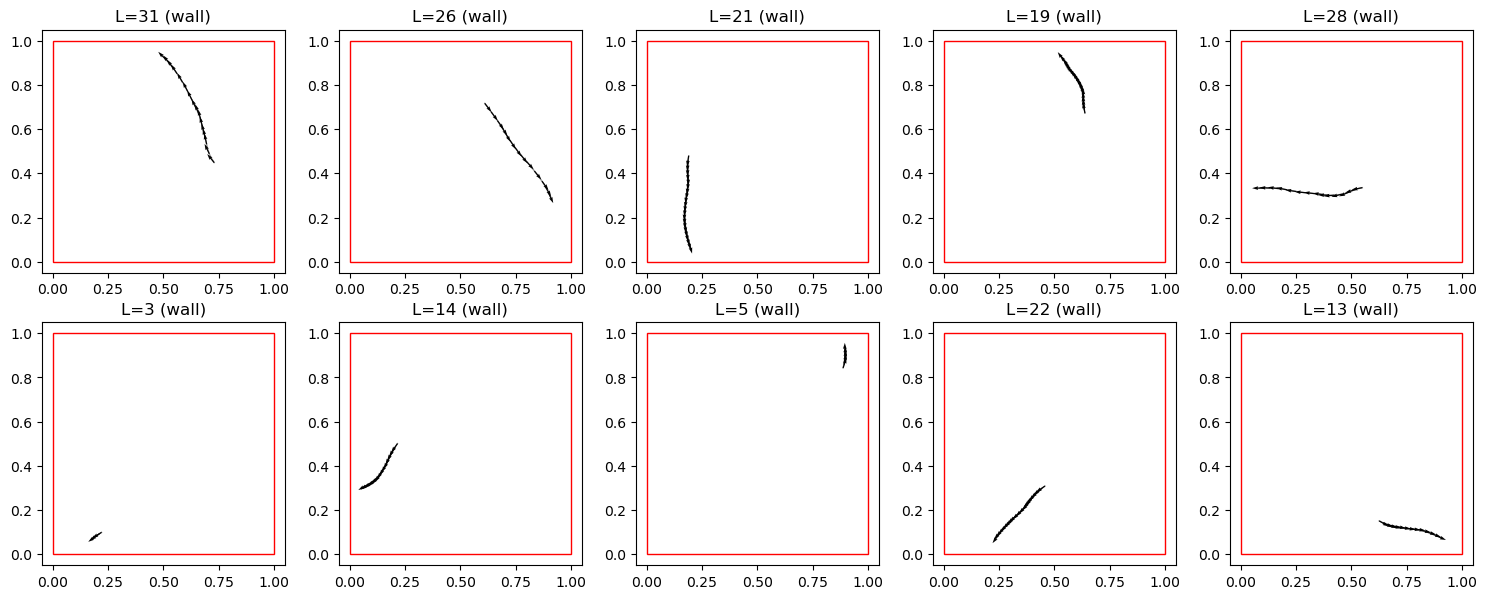

In [21]:
if __name__ == "__main__":
    rng = np.random.default_rng(42)
    episodes = [run_episode(rng, max_steps=500, grid_size=40, hold_k=4) for _ in range(10)]

    print("episode lengths:")
    for i, (_, s, _, term) in enumerate(episodes):
        print(f"  ep {i}: L={len(s):3d}  termination={term}")

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for ax, (_, s, _, term) in zip(axes.flat, episodes):
        arrow_every = max(1, len(s) // 12)
        show_trajectory(s, ax=ax, title=f"L={len(s)} ({term})", arrow_every=arrow_every)
    fig.tight_layout()
    plt.show()

Pick the longest episode and eyeball a strip of its rendered frames. Confirms the renderer and dynamics agree.

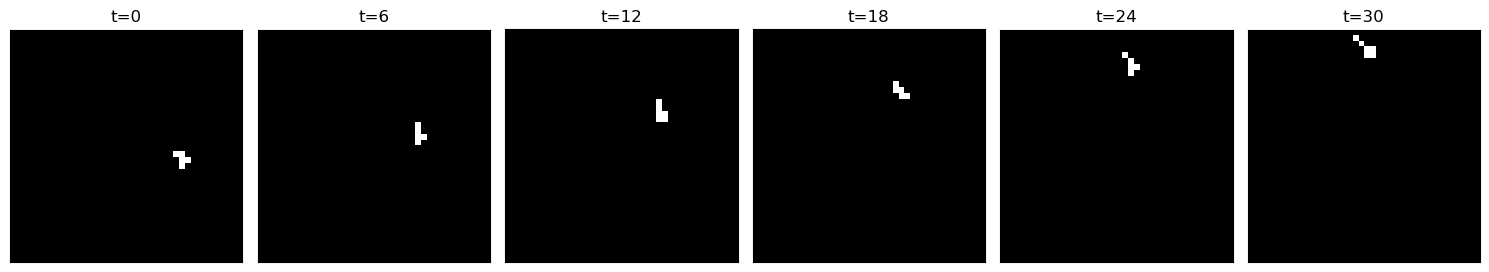

In [22]:
if __name__ == "__main__":
    longest = max(episodes, key=lambda e: len(e[1]))
    frames, states, _, term = longest
    L = len(states)
    key_indices = np.linspace(0, L - 1, 6, dtype=int)
    show_frame_strip(
        [frames[i] for i in key_indices],
        titles=[f"t={i}" for i in key_indices],
        figsize=(15, 3),
    )
    plt.show()

## Dataset collection

Stream episodes straight to one HDF5 file at constant memory. Datasets are resizable and chunked, with gzip on frames only (states/actions are tiny). Episodes shorter than `min_length` are dropped to avoid degenerate spawn-and-crash runs.

Every generative parameter is stored as an HDF5 attr, so the file is self-describing: `h5py.File(...).attrs` tells you exactly what produced it.

In [ ]:
def collect_dataset(
    path: Union[str, Path],
    n_episodes: int = N_EPISODES,
    max_steps: int = MAX_STEPS,
    grid_size: int = GRID_SIZE,
    world_bounds: tuple = WORLD_BOUNDS,
    dt: float = DT,
    hold_k: int = HOLD_K,
    v_mean: float = V_MEAN,
    v_std: float = V_STD,
    omega_mean: float = OMEGA_MEAN,
    omega_std: float = OMEGA_STD,
    min_length: int = 10,
    seed: int = SEED,
    marker: str = RENDER_MARKER,
    progress_every: int = 100,
) -> None:
    """Stream `n_episodes` random-action episodes to an HDF5 file.

    Parameters
    ----------
    path : str or Path
        Output .h5 file. Parent directory created if missing.
    n_episodes : int
        Number of episodes to attempt.
    max_steps, grid_size, world_bounds, dt, hold_k : see `run_episode`.
    v_mean, v_std, omega_mean, omega_std : see `sample_action`.
    min_length : int
        Episodes with `len(states) < min_length` are dropped.
    seed : int
        Seeds the `np.random.default_rng` used for everything.
    marker : {"none", "dot"}
        Heading cue baked into every frame. "none" stores binary uint8 frames;
        a marker stores grayscale float32 frames. Default from config.
    progress_every : int
        Print a progress line every N attempted episodes.

    n_episodes, max_steps, grid_size, hold_k, seed, marker default from config.py.

    Notes
    -----
    Stored at the top level of the HDF5 file:
      frames           (T, H, W) uint8 (binary) or float32 (marker)  gzip-compressed
      states           (T, 3)    float32
      actions          (T, 2)    float32
      episode_starts   (E,)      int64   index into the flat arrays
      episode_lengths  (E,)      int64
      termination      (E,)      uint8   0=wall, 1=timeout
    Plus the generative parameters as `.attrs` (including render_marker).
    """
    if n_episodes < 1:
        raise ValueError(f"n_episodes must be >= 1, got {n_episodes}")
    if min_length < 1:
        raise ValueError(f"min_length must be >= 1, got {min_length}")

    rng = np.random.default_rng(seed)
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    frames_dtype = "uint8" if marker == "none" else "float32"

    with h5py.File(path, "w") as f:
        frames_ds = f.create_dataset(
            "frames",
            shape=(0, grid_size, grid_size),
            maxshape=(None, grid_size, grid_size),
            dtype=frames_dtype,
            chunks=(64, grid_size, grid_size),
            compression="gzip",
        )
        states_ds = f.create_dataset(
            "states", shape=(0, 3), maxshape=(None, 3),
            dtype="float32", chunks=(512, 3),
        )
        actions_ds = f.create_dataset(
            "actions", shape=(0, 2), maxshape=(None, 2),
            dtype="float32", chunks=(512, 2),
        )

        episode_starts = []
        episode_lengths = []
        term_codes = []  # 0 = wall, 1 = timeout
        total = 0
        kept = 0

        for ep in range(n_episodes):
            frames, states, actions, termination = run_episode(
                rng,
                max_steps=max_steps, grid_size=grid_size,
                world_bounds=world_bounds, dt=dt, hold_k=hold_k,
                v_mean=v_mean, v_std=v_std,
                omega_mean=omega_mean, omega_std=omega_std,
                marker=marker,
            )
            if len(states) < min_length:
                continue

            L = len(states)
            for ds, block in ((frames_ds, frames), (states_ds, states), (actions_ds, actions)):
                ds.resize(ds.shape[0] + L, axis=0)
                ds[-L:] = block

            episode_starts.append(total)
            episode_lengths.append(L)
            term_codes.append(0 if termination == "wall" else 1)
            total += L
            kept += 1

            if (ep + 1) % progress_every == 0:
                print(f"{ep + 1}/{n_episodes} attempted, {kept} kept, {total} transitions")

        f.create_dataset("episode_starts",  data=np.asarray(episode_starts,  dtype=np.int64))
        f.create_dataset("episode_lengths", data=np.asarray(episode_lengths, dtype=np.int64))
        f.create_dataset("termination",     data=np.asarray(term_codes,      dtype=np.uint8))

        # Generative parameters: file is self-describing.
        f.attrs["grid_size"] = grid_size
        f.attrs["world_bounds"] = np.asarray(world_bounds, dtype=np.float64)
        f.attrs["dt"] = dt
        f.attrs["hold_k"] = hold_k
        f.attrs["max_steps"] = max_steps
        f.attrs["min_length"] = min_length
        f.attrs["seed"] = seed
        f.attrs["render_marker"] = marker
        f.attrs["v_mean"] = v_mean
        f.attrs["v_std"] = v_std
        f.attrs["omega_mean"] = omega_mean
        f.attrs["omega_std"] = omega_std
        f.attrs["n_episodes_attempted"] = n_episodes
        f.attrs["n_episodes_kept"] = kept
        f.attrs["total_transitions"] = total
        f.attrs["indexing_convention"] = (
            "frames[t] = render of states[t]; "
            "actions[t] applied at states[t] -> states[t+1] for t < L-1; "
            "final action has no recorded successor"
        )

    print(f"Done. {kept}/{n_episodes} episodes kept, {total} transitions -> {path}")

## Generate the dataset

The real run. With the constants' sampling policy and `hold_k=4`, episodes average tens of steps before hitting a wall. Bump `hold_k` higher if they come out too short.

In [ ]:
if __name__ == "__main__":
    out = DATA_PATH
    collect_dataset(out, n_episodes=N_EPISODES, max_steps=MAX_STEPS, hold_k=HOLD_K, seed=SEED)

    # Write coverage diagnostics next to the dataset.
    from data.coverage import plot_coverage
    plot_coverage(out, show=False)

## Inspect run

Quick read-back to confirm shapes, attrs, and an example trajectory survived the round-trip.

In [ ]:
if __name__ == "__main__":
    with h5py.File(DATA_PATH, "r") as f:
        print("datasets:")
        for name, ds in f.items():
            print(f"  {name:20s} shape={ds.shape}  dtype={ds.dtype}")
        print("\nattrs:")
        for k, v in f.attrs.items():
            print(f"  {k:25s} = {v}")

        lens = f["episode_lengths"][:]
        print(f"\nepisode lengths: min={lens.min()}, median={int(np.median(lens))}, max={lens.max()}, mean={lens.mean():.1f}")

        # Plot one trajectory by re-slicing into the flat array.
        starts = f["episode_starts"][:]
        idx = int(np.argmax(lens))  # longest episode
        s, e = starts[idx], starts[idx] + lens[idx]
        states = f["states"][s:e]

    show_trajectory(states, title=f"longest episode (L={len(states)})", arrow_every=max(1, len(states) // 15))
    plt.show()